# 04 — XGBoost (weekly silver volatility)

XGBoost on the **same HAR + EXOG feature set** as the Random Forest notebook, so the
two tree models are directly comparable — this mirrors the aligned
`weekly/04_random_forest.ipynb` / `weekly/05_xgboost.ipynb` pair on the returns side.

Hyperparameters are tuned on the validation split, then the model is re-fit on
train+val. Features come from `volatility_weekly.csv` — run `00_features.ipynb` first.


## Setup


In [1]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
from vol_utils import vol_evaluate, vol_period_metrics
from eval_utils import PERIODS
import warnings; warnings.filterwarnings('ignore')

SEED = 42
plt.rcParams['figure.figsize'] = (10, 4)

frame = pd.read_csv('../../data/processed/volatility_weekly.csv',
                    parse_dates=['Date']).set_index('Date')
train_df = frame[frame['split'] == 'train']
val_df   = frame[frame['split'] == 'val']
test_df  = frame[frame['split'] == 'test']
trval_df = frame[frame['split'] != 'test']

FEATS_HAR  = ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
FEATS_EXOG = [c for c in frame.columns if c.endswith('_rv_lag1') and not c.startswith('silver')]
FEATS_ALL  = FEATS_HAR + FEATS_EXOG
print('features:', FEATS_ALL)


features: ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1', 'gold_rv_lag1', 'copper_rv_lag1', 'usd_rv_lag1', 'sp500_rv_lag1', 'vix_rv_lag1', 'oil_rv_lag1']


## 1. Hyperparameter tuning

Small grid search over tree count / depth / learning rate. Each configuration is fit on
the train split and scored by RMSE on the validation split; the lowest-RMSE
configuration is kept.


In [2]:
y_tr = train_df['target']; y_v = val_df['target']

def tune_xgb(X_tr, y_tr, X_v, y_v):
    grid = ParameterGrid({'n_estimators': [200, 400], 'max_depth': [3, 5],
                          'learning_rate': [0.03, 0.1]})
    best = (np.inf, None)
    for p in grid:
        m = XGBRegressor(random_state=SEED, verbosity=0, **p).fit(X_tr, y_tr)
        rmse = np.sqrt(mean_squared_error(y_v, m.predict(X_v)))
        if rmse < best[0]:
            best = (rmse, p)
    return best[1]

xgb_best = tune_xgb(train_df[FEATS_ALL], y_tr, val_df[FEATS_ALL], y_v)
print('XGB best params:', xgb_best)


XGB best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


## 2. Refit on train+val and evaluate

The best configuration is re-fit on train+val combined, then scored once on the test
set.


In [3]:
y_test    = test_df['target'].values
prev_test = test_df['rv_w_lag1'].values

xgb = XGBRegressor(random_state=SEED, verbosity=0, importance_type='gain',
                   **xgb_best).fit(trval_df[FEATS_ALL], trval_df['target'])
xgb_pred = xgb.predict(test_df[FEATS_ALL])

results = [vol_evaluate('XGB (HAR+EXOG)', y_test, xgb_pred, prev_test)]


XGB (HAR+EXOG)                  RMSE=0.03702  MAE=0.01970  R2=+0.052  DCA=0.697


## 3. Feature importance

Gain-based importance — the average gain in accuracy each feature brings to the splits
it appears in. As with the Random Forest, the question is whether any EXOG cross-asset
RV earns non-trivial importance alongside the HAR lags.


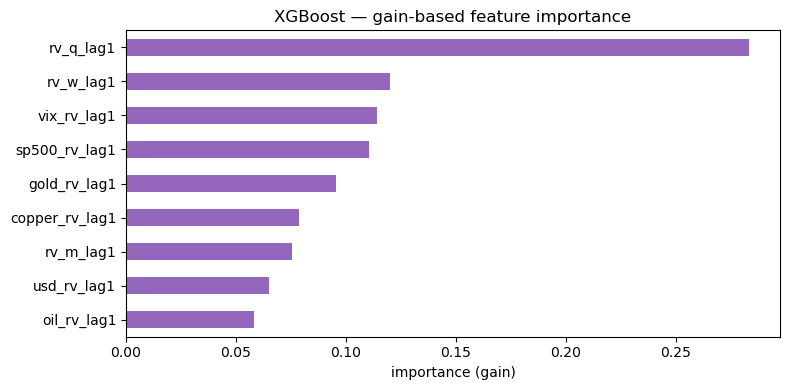

rv_q_lag1         0.2832
rv_w_lag1         0.1198
vix_rv_lag1       0.1140
sp500_rv_lag1     0.1104
gold_rv_lag1      0.0955
copper_rv_lag1    0.0787
rv_m_lag1         0.0755
usd_rv_lag1       0.0648
oil_rv_lag1       0.0580
dtype: float32

In [4]:
imp = pd.Series(xgb.feature_importances_, index=FEATS_ALL).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
imp.plot.barh(ax=ax, color='#9467bd')
ax.set_title('XGBoost — gain-based feature importance'); ax.set_xlabel('importance (gain)')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)


## 4. Sub-period breakdown

RMSE and DCA split by calendar year, using the shared `PERIODS` definition.


In [5]:
period_xgb = vol_period_metrics(y_test, xgb_pred, prev_test, test_df.index, PERIODS)
period_xgb.to_csv('../../data/processed/period_xgb_volatility.csv')
period_xgb.round(4)


,n,RMSE,DCA
Period,,,
2023 (choppy),52,0.0154,0.7308
2024 (bull start),52,0.0197,0.7115
2025 (bull run),52,0.0285,0.6923
2026 (YTD),19,0.0932,0.5789
── Full test ──,175,0.0370,0.6971


## 5. Save outputs

- `metrics_xgb_volatility.csv` — XGBoost headline metrics
- `pred_xgb_volatility.csv` — test-set predictions, consumed by `evaluation.ipynb`


In [6]:
pd.DataFrame(results).to_csv('../../data/processed/metrics_xgb_volatility.csv', index=False)

pred_xgb = pd.DataFrame({'actual': y_test, 'prev': prev_test, 'xgb': xgb_pred}, index=test_df.index)
pred_xgb.to_csv('../../data/processed/pred_xgb_volatility.csv', index_label='Date')
print('Saved metrics_xgb_volatility.csv + pred_xgb_volatility.csv')
pd.DataFrame(results).round(5)


Saved metrics_xgb_volatility.csv + pred_xgb_volatility.csv


,model,rmse,mae,r2,dca
0,XGB (HAR+EXOG),0.03702,0.0197,0.05242,0.69714
